In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

# Part-1

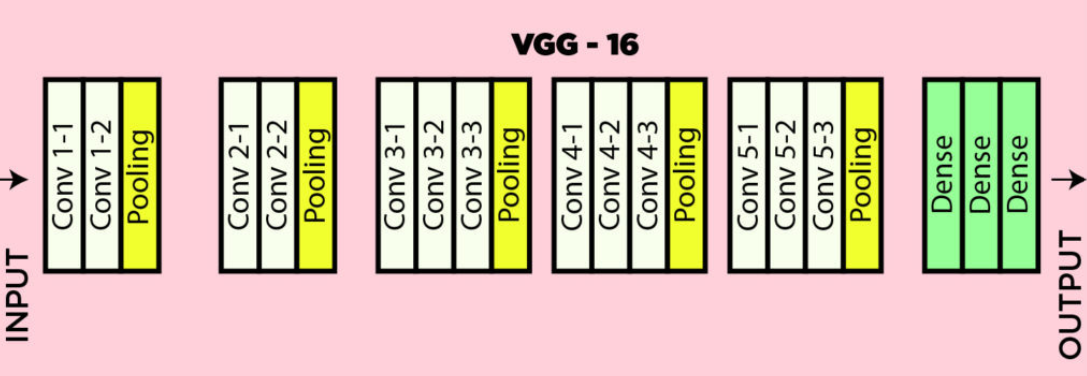

In [ ]:
vgg = VGG16(
    weights='imagenet',
    include_top = True,
    input_shape=(224, 224, 3)
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
for layer in vgg.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer          | Type: InputLayer           | Trainable: True
block1_conv1         | Type: Conv2D               | Trainable: True
block1_conv2         | Type: Conv2D               | Trainable: True
block1_pool          | Type: MaxPooling2D         | Trainable: True
block2_conv1         | Type: Conv2D               | Trainable: True
block2_conv2         | Type: Conv2D               | Trainable: True
block2_pool          | Type: MaxPooling2D         | Trainable: True
block3_conv1         | Type: Conv2D               | Trainable: True
block3_conv2         | Type: Conv2D               | Trainable: True
block3_conv3         | Type: Conv2D               | Trainable: True
block3_pool          | Type: MaxPooling2D         | Trainable: True
block4_conv1         | Type: Conv2D               | Trainable: True
block4_conv2         | Type: Conv2D               | Trainable: True
block4_conv3         | Type: Conv2D               | Trainable: True
block4_pool          | Type: MaxPooling2D       

In [ ]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Type Finetuning-1

In [ ]:
model = Sequential()
model.add(vgg)
model.add(Dense(1,activation='sigmoid'))

In [ ]:
# It is from Functional API
# x = vgg.layers[-2].output
# output = Dense(1, activation='sigmoid')(x)
# model = Model(inputs=vgg.input, outputs=output)
# model.summary()

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/val',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

Found 838 files belonging to 2 classes.
Found 390 files belonging to 2 classes.


In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
from tensorflow import keras

model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_ds,epochs=3,validation_data=validation_ds,verbose=1)

Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.4864 - loss: 0.6933 - val_accuracy: 0.5026 - val_loss: 0.6929
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 533ms/step - accuracy: 0.5082 - loss: 0.6927 - val_accuracy: 0.5590 - val_loss: 0.6923
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 561ms/step - accuracy: 0.5709 - loss: 0.6921 - val_accuracy: 0.6718 - val_loss: 0.6896


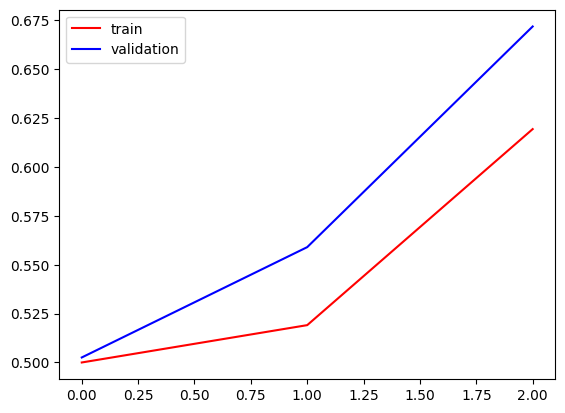

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# Path to one test image
img_path = 'data/test/cat.jpg'

In [ ]:
# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalization (same as training)

In [ ]:
# Predict
prediction = model.predict(img_array)

# Interpret result
label = "Dog " if prediction[0][0] > 0.5 else "Cat 🐱"
confidence = prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


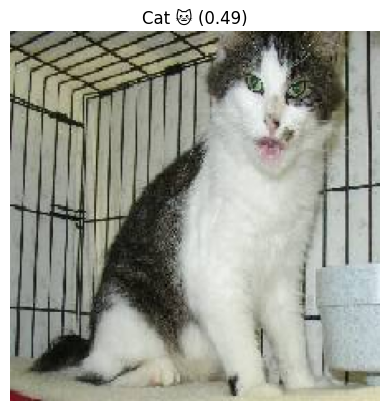

In [ ]:
# Show result
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis('off')
plt.show()


## Type Finetuning-2

In [ ]:
vgg_conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in vgg_conv_base.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer_2        | Type: InputLayer           | Trainable: True
block1_conv1         | Type: Conv2D               | Trainable: True
block1_conv2         | Type: Conv2D               | Trainable: True
block1_pool          | Type: MaxPooling2D         | Trainable: True
block2_conv1         | Type: Conv2D               | Trainable: True
block2_conv2         | Type: Conv2D               | Trainable: True
block2_pool          | Type: MaxPooling2D         | Trainable: True
block3_conv1         | Type: Conv2D               | Trainable: True
block3_conv2         | Type: Conv2D               | Trainable: True
block3_conv3         | Type: Conv2D               | Trainable: True
block3_pool          | Type: MaxPooling2D         | Trainable: True
block4_conv1         | Type: Conv2D               | Trainable: True
block4_conv2         | Type: Conv2D               | Trainable: True
block4_conv3         | Type: Conv2D               | Trainable: True
block4_pool          | Type: MaxPooling2D       

In [ ]:
vgg_conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(vgg_conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

# Part-3

In [ ]:
vgg_conv_base.trainable = False
set_trainable = False

In [ ]:
vgg_conv_base.trainable

False

In [ ]:
vgg_conv_base.layers

[<InputLayer name=input_layer_2, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [ ]:
for layer in vgg_conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

In [ ]:
for layer in vgg_conv_base.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer_2        | Type: InputLayer           | Trainable: False
block1_conv1         | Type: Conv2D               | Trainable: False
block1_conv2         | Type: Conv2D               | Trainable: False
block1_pool          | Type: MaxPooling2D         | Trainable: False
block2_conv1         | Type: Conv2D               | Trainable: False
block2_conv2         | Type: Conv2D               | Trainable: False
block2_pool          | Type: MaxPooling2D         | Trainable: False
block3_conv1         | Type: Conv2D               | Trainable: False
block3_conv2         | Type: Conv2D               | Trainable: False
block3_conv3         | Type: Conv2D               | Trainable: False
block3_pool          | Type: MaxPooling2D         | Trainable: False
block4_conv1         | Type: Conv2D               | Trainable: False
block4_conv2         | Type: Conv2D               | Trainable: False
block4_conv3         | Type: Conv2D               | Trainable: False
block4_pool          | Type: MaxPo

In [ ]:
model = Sequential()
model.add(vgg_conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

# Lets understand Transfer Learning and Finetuning with BERT now.

In [ ]:
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which 

In [ ]:
from transformers import BertTokenizer
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer, BertForSequenceClassification
from transformers import BertModel


In [ ]:
# Load dataset (you can replace this with your CSV)
dataset = load_dataset("imdb", split='train[:2000]')
dataset = dataset.train_test_split(test_size=0.2)
train_texts = dataset['train']['text']
train_labels = dataset['train']['label']
val_texts = dataset['test']['text']
val_labels = dataset['test']['label']

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, return_tensors='pt')

In [ ]:
dataset = dataset.map(lambda x: tokenizer(x['text'], padding="max_length", truncation=True), batched=True)
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
# Load pre-trained model with new output head
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2  # For binary classification
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for param in model.bert.parameters():
    # param.requires_grad = False
    print(len(param))


30522
512
2
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768
768
768
768
768
768
768
768
768
3072
3072
768
768
768
768
768
768


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")


Total parameters: 109483778


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")


Trainable parameters: 109483778


In [ ]:
for name, param in model.named_parameters():
    print(f"{name:50} | Shape: {tuple(param.shape)} | Trainable: {param.requires_grad}")


bert.embeddings.word_embeddings.weight             | Shape: (30522, 768) | Trainable: True
bert.embeddings.position_embeddings.weight         | Shape: (512, 768) | Trainable: True
bert.embeddings.token_type_embeddings.weight       | Shape: (2, 768) | Trainable: True
bert.embeddings.LayerNorm.weight                   | Shape: (768,) | Trainable: True
bert.embeddings.LayerNorm.bias                     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.query.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.query.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.key.weight     | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.key.bias       | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.value.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.value.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.output.den

In [ ]:
print(model.bert.embeddings)                 # Embedding layer
print(model.bert.encoder.layer[11])          # Last Transformer block
print(model.classifier)                      # Output classification head


BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): 

In [ ]:
print(model)  # Full model architecture, all layers


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
print(model.config)  # Model config: hidden size, num labels, dropout, etc.

BertConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
# Training args
training_args = TrainingArguments(
    output_dir="./bert_output_1",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
     report_to="none"
)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)


In [ ]:



trainer.train()


Step,Training Loss
500,0.002900


TrainOutput(global_step=600, training_loss=0.002436585339407126, metrics={'train_runtime': 487.7992, 'train_samples_per_second': 9.84, 'train_steps_per_second': 1.23, 'total_flos': 1262933065728000.0, 'train_loss': 0.002436585339407126, 'epoch': 3.0})

# unfreeze couple of last layer then train it


In [ ]:
from transformers import BertModel, BertTokenizer, PreTrainedModel, Trainer, TrainingArguments, BertConfig
from transformers.modeling_outputs import SequenceClassifierOutput

In [ ]:
class BertBinaryClassifier(PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(config.hidden_size, 2)  # Binary classification logits

        # Freeze all layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # Unfreeze last 2 layers
        for layer in self.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Unfreeze pooler
        for param in self.bert.pooler.parameters():
            param.requires_grad = True

        # Classifier should be trainable
        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )


In [ ]:
config = BertConfig.from_pretrained("bert-base-uncased", num_labels=2)
model = BertBinaryClassifier(config)

training_args = TrainingArguments(
    output_dir="./bert_last2layers_finetune",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no",
    report_to="none",  # Disable wandb etc.
    logging_dir="./logs"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

trainer.train()

Step,Training Loss
500,0.004000


TrainOutput(global_step=600, training_loss=0.0032980195879160116, metrics={'train_runtime': 188.5181, 'train_samples_per_second': 25.462, 'train_steps_per_second': 3.183, 'total_flos': 1262933065728000.0, 'train_loss': 0.0032980195879160116, 'epoch': 3.0})

In [ ]:
def predict_text(text, model, tokenizer):
    # Preprocess input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128)

    # Put model in eval mode
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()
        confidence = torch.softmax(logits, dim=1)[0][predicted_class].item()

    label_name = "Positive ✅" if predicted_class == 1 else "Negative ❌"
    print(f"Text: {text}")
    print(f"Prediction: {label_name} (Confidence: {confidence:.2f})")
    return predicted_class, confidence
